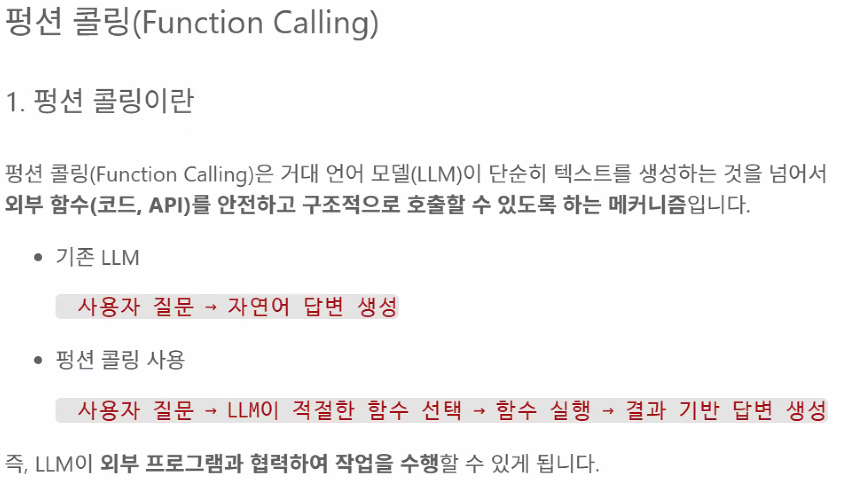

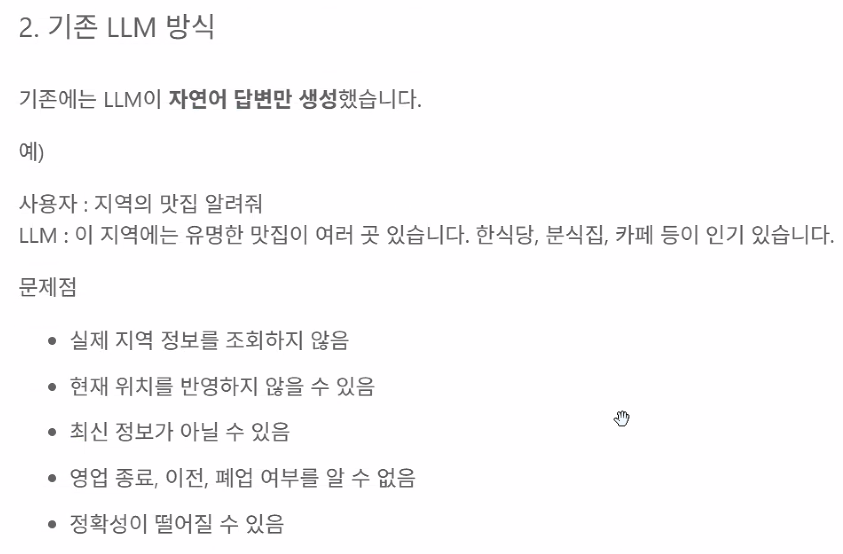

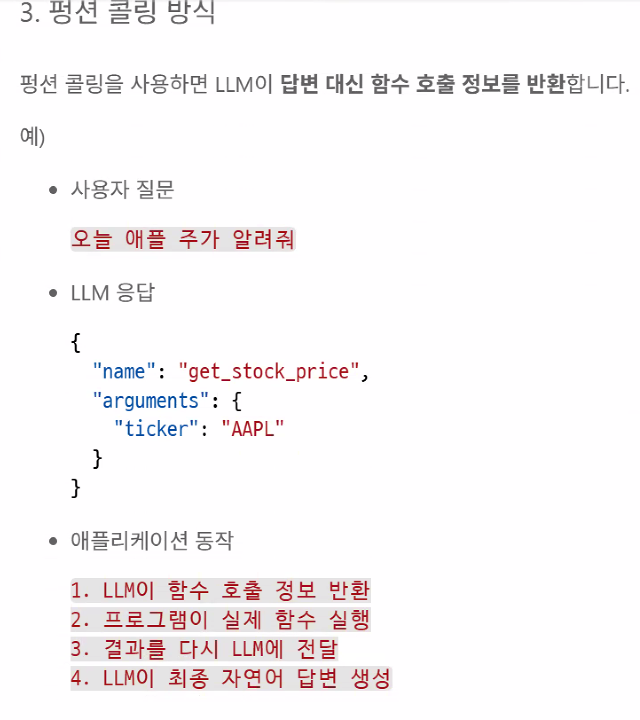

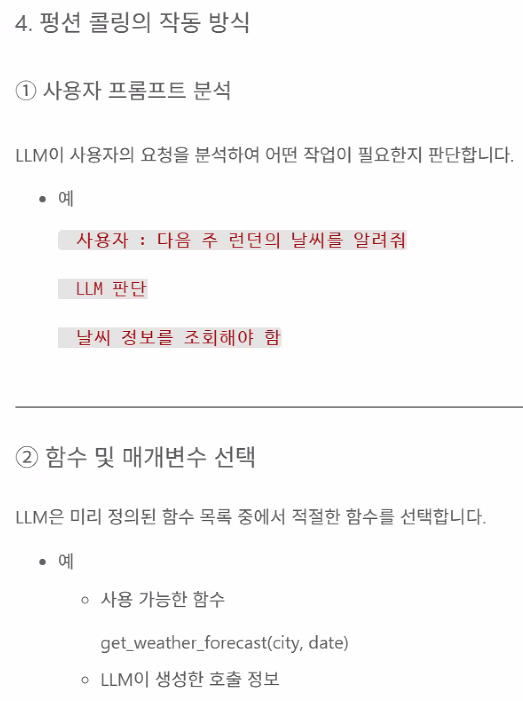

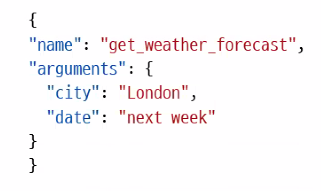

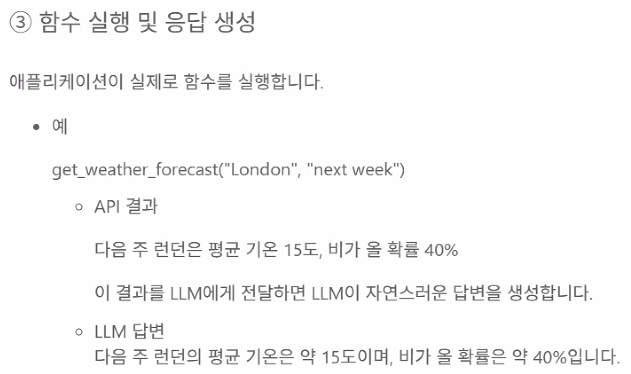

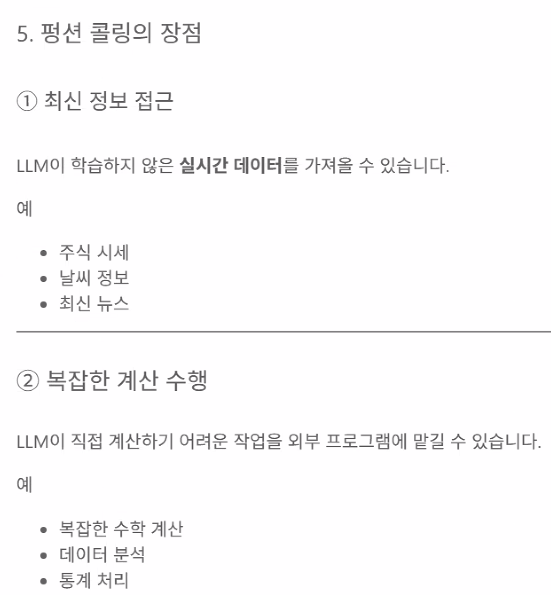

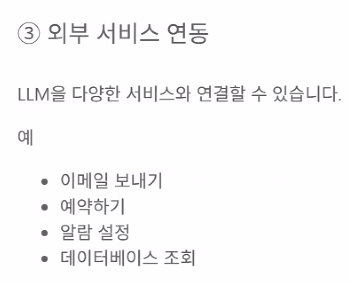

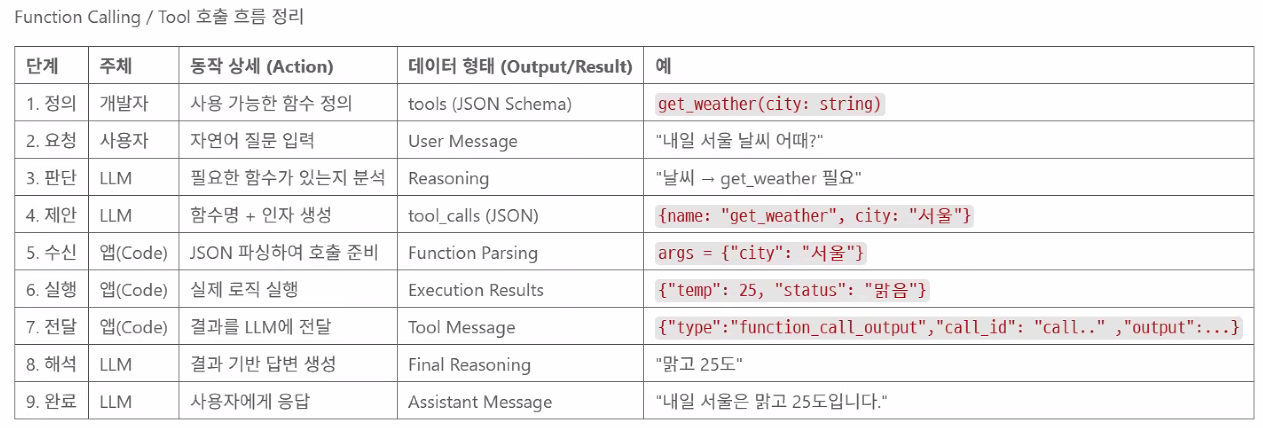

In [1]:
%pip install yfinance

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 28.8 MB/s  0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15702 sha256=80e1f5b0834f961cd8b59df557948c897cb03d6142fdd12957db9a23d0c07d98
  Stored in directory: c:\users\강의실\appdata\local\pip\cache\wheels\cc\bd\6f\664d62c99327abeef7d86489e6631cbf45b56fbf7ef1d6ef00
Successfully built multitasking

   ---------- ----------------------------- 2/8 [websockets]
   ------------------------------ --------- 6/8 [curl_cffi]
   ---------------------------------------- 8/8 [yfinance]

Note: you may need to r

In [2]:
# OpenAI Python SDK에서 OpenAI 클래스를 가져옵니다.
# 이 클래스를 사용해서 OpenAI API와 통신하는 클라이언트 객체를 만듭니다
from openai import OpenAI

# JSON 데이터를 다루기 위한 파이썬 기본 라이브러리입니다.
# 문자열 형태의 JSON을 파이썬 딕셔너리로 바꾸거나, 파이썬 객체를 JSON 문자열로 바꿀 때 사용합니다.
# json.loads(...) : JSON 문자열 -> 파이썬 객체
# json.dumps(...) : 파이썬 객체 -> JSON 문자열
import json

from dotenv import load_dotenv

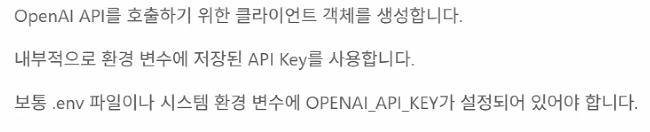

In [3]:
load_dotenv()
client = OpenAI()

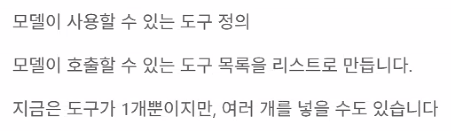

In [4]:
tools = [
    {
        
    }
]

In [5]:
from openai import OpenAI
import json

client = OpenAI()

# 1. Define a list of callable tools for the model
tools = [
    {
        "type": "function",
        "name": "get_horoscope",
        "description": "Get today's horoscope for an astrological sign.",
        "parameters": {
            "type": "object",
            "properties": {
                "sign": {
                    "type": "string",
                    "description": "An astrological sign like Taurus or Aquarius",
                },
            },
            "required": ["sign"],
        },
    },
]

def get_horoscope(sign):
    return f"{sign}: Next Tuesday you will befriend a baby otter."

# Create a running input list we will add to over time
input_list = [
    {"role": "user", "content": "What is my horoscope? I am an Aquarius."}
]

# 2. Prompt the model with tools defined
response = client.responses.create(
    model="gpt-4.1-nano",
    tools=tools,
    input=input_list,
)

# Save function call outputs for subsequent requests
input_list += response.output

for item in response.output:
    if item.type == "function_call":
        if item.name == "get_horoscope":
            # 3. Execute the function logic for get_horoscope
            horoscope = get_horoscope(json.loads(item.arguments))
            
            # 4. Provide function call results to the model
            input_list.append({
                "type": "function_call_output",
                "call_id": item.call_id,
                "output": json.dumps({
                    "horoscope": horoscope
                })
            })

print("Final input:")
print(input_list)

response = client.responses.create(
    model="gpt-4.1-nano",
    instructions="Respond only with a horoscope generated by a tool.",
    tools=tools,
    input=input_list,
)

# 5. The model should be able to give a response!
print("Final output:")
print(response.model_dump_json(indent=2))
print("\n" + response.output_text)

Final input:
[{'role': 'user', 'content': 'What is my horoscope? I am an Aquarius.'}, ResponseFunctionToolCall(arguments='{"sign":"Aquarius"}', call_id='call_VXVJYhxfwFAlBs9PK5LAF6lw', name='get_horoscope', type='function_call', id='fc_04fa7b71701e8b4b0069bca355b308819784148506834ad3d1', namespace=None, status='completed'), {'type': 'function_call_output', 'call_id': 'call_VXVJYhxfwFAlBs9PK5LAF6lw', 'output': '{"horoscope": "{\'sign\': \'Aquarius\'}: Next Tuesday you will befriend a baby otter."}'}]
Final output:
{
  "id": "resp_04fa7b71701e8b4b0069bca3561c048197bae8dc9bba3dd8e3",
  "created_at": 1773970262.0,
  "error": null,
  "incomplete_details": null,
  "instructions": "Respond only with a horoscope generated by a tool.",
  "metadata": {},
  "model": "gpt-4.1-nano-2025-04-14",
  "object": "response",
  "output": [
    {
      "id": "msg_04fa7b71701e8b4b0069bca3566e2c81978e16db60d6e89b08",
      "content": [
        {
          "annotations": [],
          "text": "Your horoscope s

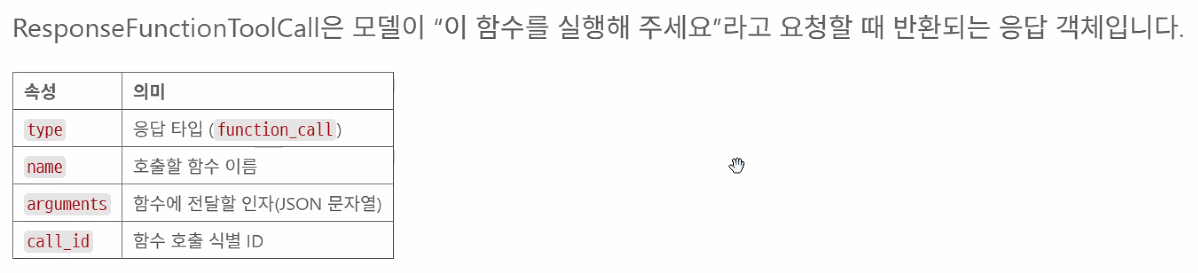

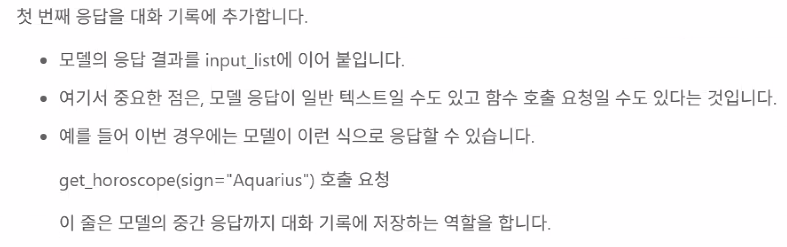